In [ ]:
import torch
import numpy as np
from src.util.celano_lab_scripts import process_image

IMG_SIZE_UM=2.0
fp = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/data/raw-data/1-23-25/img3cbMoS2-Sef-New-Area1-position 4 (2um-good) (hivac)_250102_Current_Backward_013.npy"
data = torch.Tensor(np.load(fp)).unsqueeze(0)
data_subset = data[:, :128, :128]
process_image(data, 2.0)

{'coverage_percentage': 98.72093200683594,
 'total_len_detected_curves': 27.42259545205161,
 'total_area_circular_shapes': 1.0794525146484375,
 'total_area_extended_shapes': 0.0282440185546875,
 'total_defect_area': 0.0004225526936352253,
 'num_circular_shapes': 1409,
 'num_extended_shapes': 5,
 'num_curved_lines': 5,
 'average_surface_current': 13.335134774195012}

In [6]:
import pprint

from tqdm import tqdm
from src.datasets.mos2_sef import MOS2SEFDataset, Formulation
from src.models.our_method.swin_cafm import SwinCAFM

model = SwinCAFM.get().cuda().float()
model.eval()

formulation = Formulation.P_Y_BAR_Y_SPARSE
train_dataset = MOS2SEFDataset("train", formulation, 128, 1, 750)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)
val_dataset = MOS2SEFDataset("val", formulation, 128, 1, 250)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

IMG_SIZE_UM=2.0
values = {}

@torch.no_grad()
def sample():
    
    for dataloader in [train_dataloader, val_dataloader]:
        for i, data in tqdm(enumerate(dataloader), total=len(dataloader)):
            y = data['y']
            mask = data['mask']
            y_sparse = (mask * y).cuda().float()
            y_hat = model(y_sparse)
            char_data = process_image(y_hat, IMG_SIZE_UM)
            for k, v in char_data.items():
                if k not in values:
                    values[k] = []
                values[k].append(v)
                
sample()

100%|██████████| 250/250 [00:22<00:00, 11.32it/s]


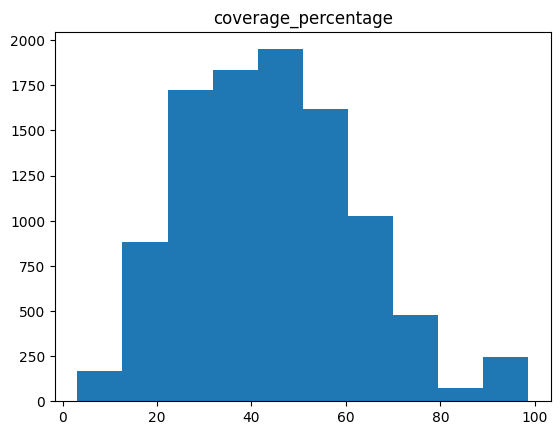

mean: 44.2051477051, std: 18.1699030925


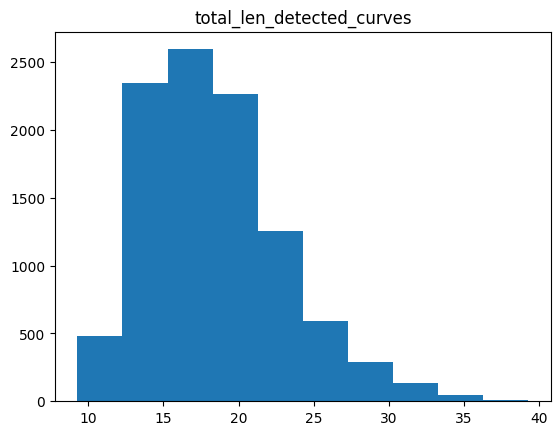

mean: 18.4042771850, std: 4.5783586012


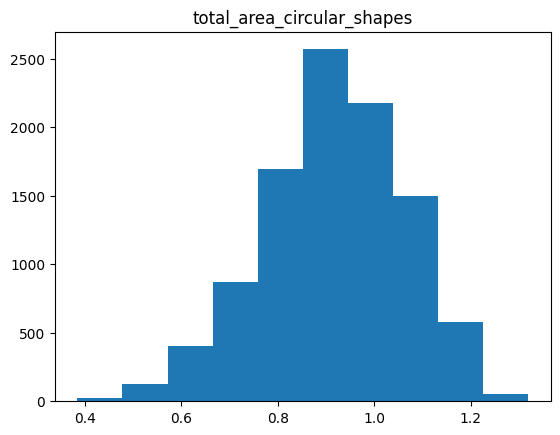

mean: 0.9159228271, std: 0.1469245674


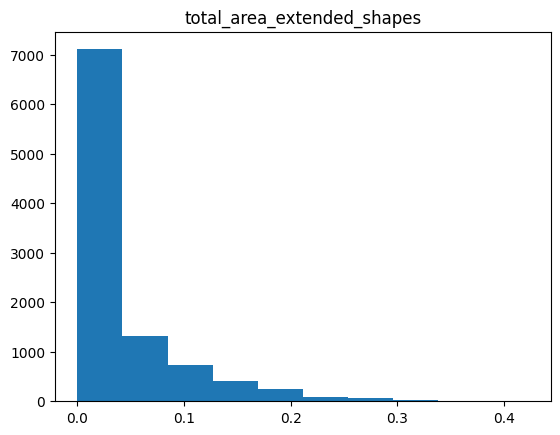

mean: 0.0322582764, std: 0.0596897683


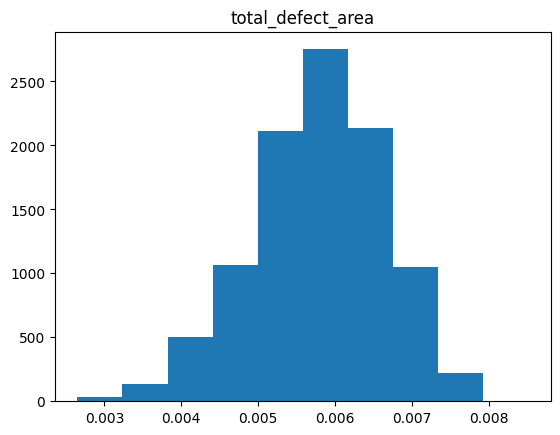

mean: 0.0057872382, std: 0.0008519035


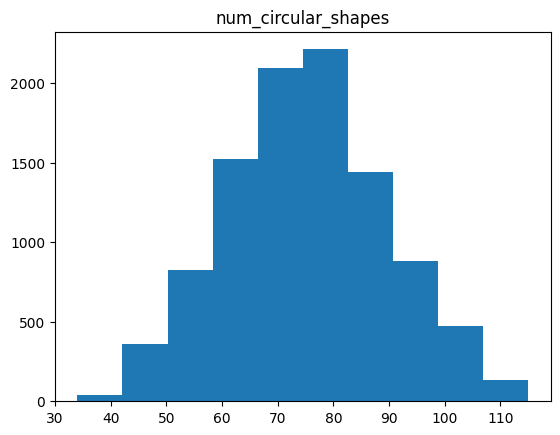

mean: 75.2265000000, std: 14.1692059675


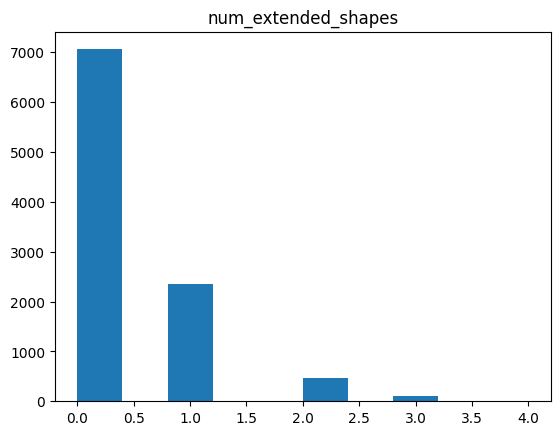

mean: 0.3658000000, std: 0.6335537546


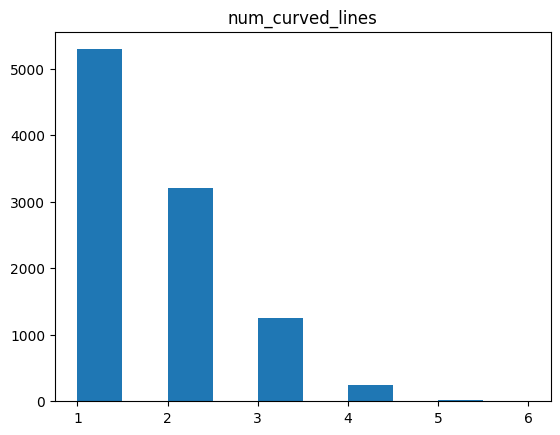

mean: 1.6506000000, std: 0.8053071712


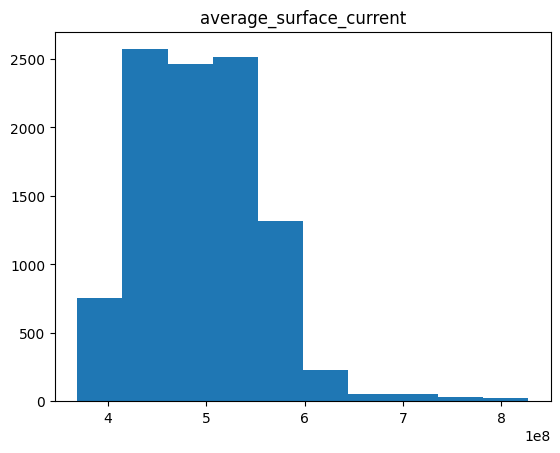

mean: 495686994.9221611619, std: 62729659.3002319783


In [6]:
import matplotlib.pyplot as plt

# plot a histogram of all values; include mean and std stats
for k, v in values.items():
    plt.hist(v)
    plt.title(k)
    plt.show()
    print(f"mean: {np.mean(v):.10f}, std: {np.std(v):.10f}")

In [2]:
import pprint
import torch
import numpy as np
from src.util.celano_lab_scripts import process_image
from tqdm import tqdm
from src.datasets.mos2_sef_surrogate import MOS2SefOLDERSurrogate, Formulation

formulation = Formulation.P_Y_BAR_Y_SPARSE
train_dataset = MOS2SefOLDERSurrogate("train", formulation, 128, 1, 7500)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=1, shuffle=False, num_workers=0
)
val_dataset = MOS2SefOLDERSurrogate("val", formulation, 128, 1, 2500)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=1, shuffle=False, num_workers=0
)

IMG_SIZE_UM=2.0
values = {}
for dataloader in [train_dataloader, val_dataloader]:
    for i, data in tqdm(enumerate(dataloader)):
        data = data['y']
        data_subset = data[:, :128, :128]
        char_data = process_image(data, IMG_SIZE_UM)
        for k, v in char_data.items():
            if k not in values:
                values[k] = []
            values[k].append(v)

7500it [03:36, 34.58it/s]
2500it [01:11, 34.81it/s]


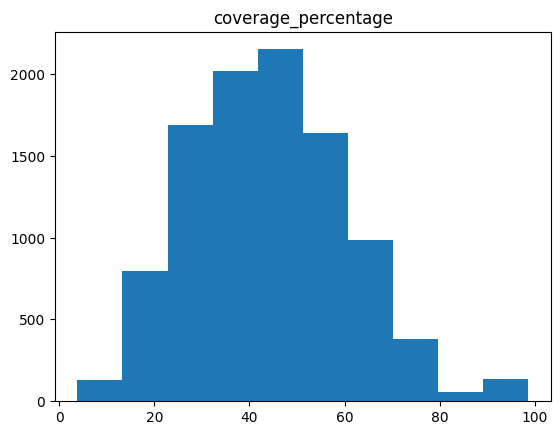

mean: 44.0220239258, std: 16.5272924169


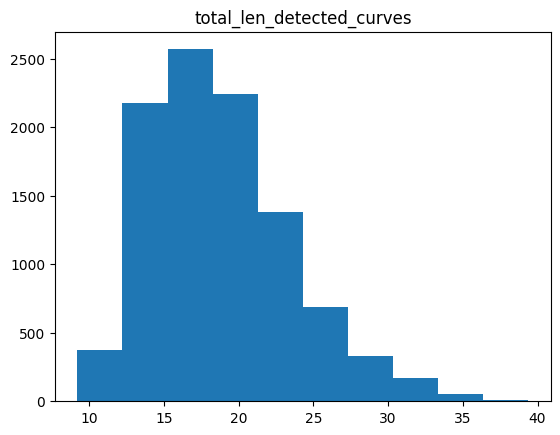

mean: 18.7612568837, std: 4.7076850134


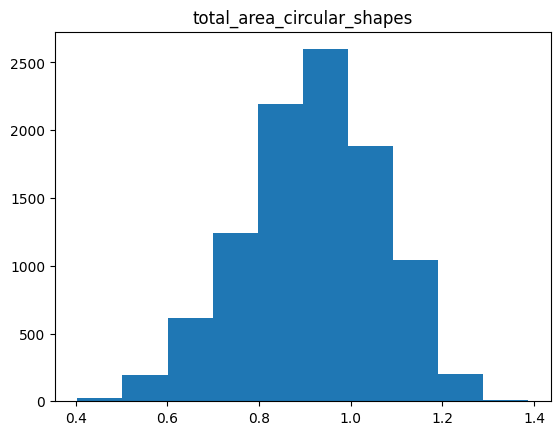

mean: 0.9166571045, std: 0.1489250416


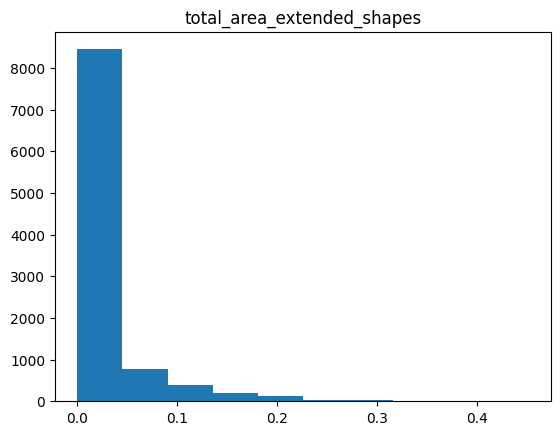

mean: 0.0176557373, std: 0.0472025983


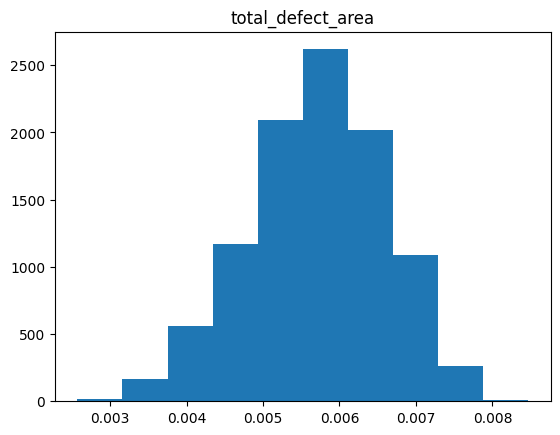

mean: 0.0057025930, std: 0.0008857003


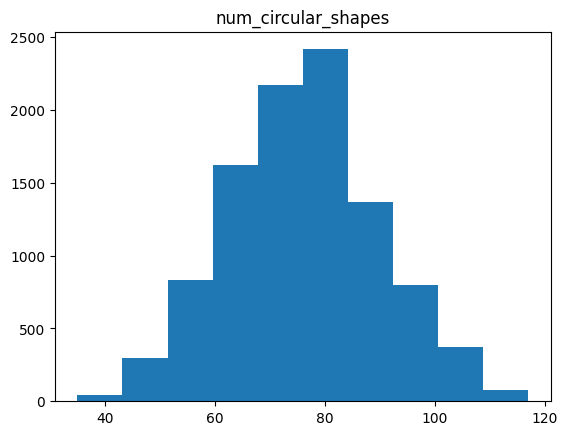

mean: 75.8980000000, std: 13.7804933148


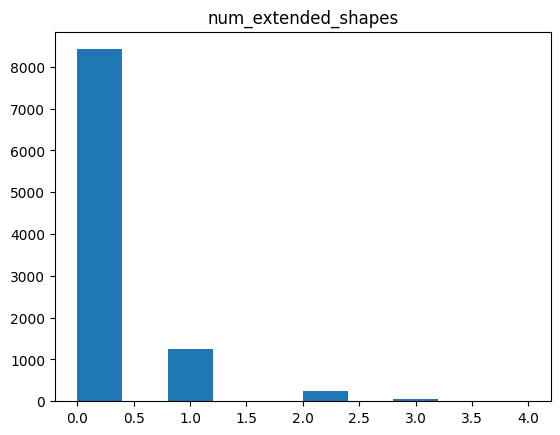

mean: 0.1977000000, std: 0.5038002680


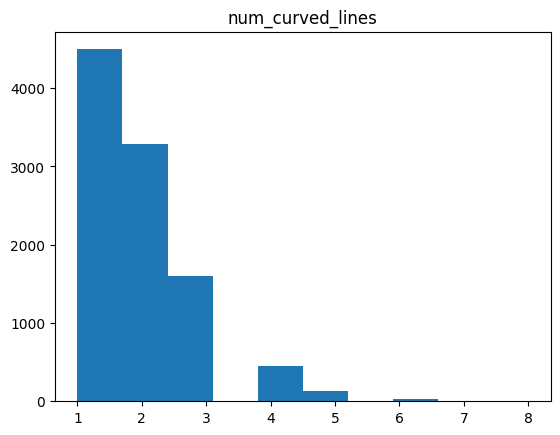

mean: 1.8537000000, std: 0.9735996662


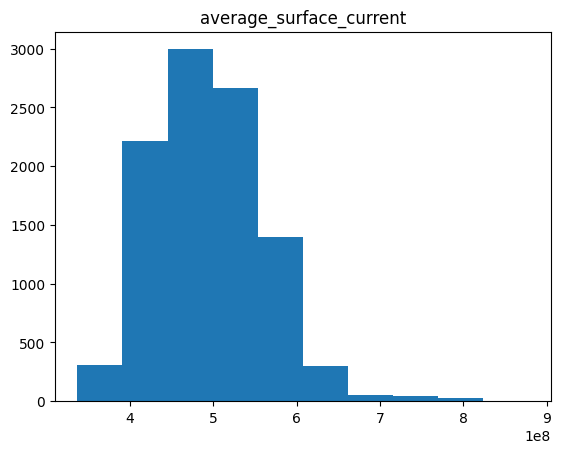

mean: 494253719.4639444351, std: 65495428.9935829639


In [3]:
import matplotlib.pyplot as plt

# plot a histogram of all values; include mean and std stats
for k, v in values.items():
    plt.hist(v)
    plt.title(k)
    plt.show()
    print(f"mean: {np.mean(v):.10f}, std: {np.std(v):.10f}")